# Actividad 18. Asesor de inversiones

Mejor combinación: [5, 0, 0, 1, 4]
Capital usado: 4900
Rendimiento: 615.0


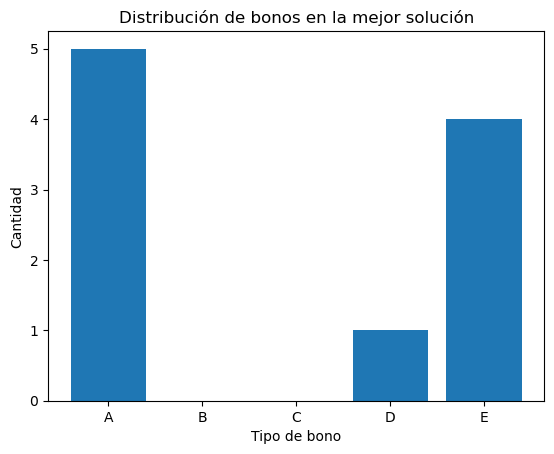

In [9]:
from random import random, randint, sample
from collections import namedtuple
import matplotlib.pyplot as plt

def capitalInvertido(individuo):
    return sum(map(lambda x, y: x * y.precio, individuo, inversiones))

def rendimiento(individuo):
    return sum(map(lambda x, y: x * y.precio * y.rendim, individuo, inversiones))

def ajustaCapital(individuo):
    ajustado = individuo[:]
    while capitalInvertido(ajustado) > capital:
        pos = randint(0, len(ajustado) - 1)
        if ajustado[pos] > 0:
            ajustado[pos] -= 1
    return ajustado

def creaIndividuo(inversiones, capital):
    individuo = [0] * len(inversiones)
    while capitalInvertido(individuo) < capital:
        eleccion = randint(0, len(inversiones) - 1)
        if individuo[eleccion] < inversiones[eleccion].cantidad:
            individuo[eleccion] += 1
    return ajustaCapital(individuo)

def cruza(poblacion, posiciones):
    L = len(poblacion[0])
    hijo = poblacion[posiciones[0]][:]
    inicio = randint(0, L - 1)
    fin = randint(inicio + 1, L)
    hijo[inicio:fin] = poblacion[posiciones[1]][inicio:fin]
    return ajustaCapital(hijo)

def muta(individuo, tasaMutacion):
    mutado = []
    for i in range(len(individuo)):
        if random() > tasaMutacion:
            mutado.append(individuo[i])
        else:
            mutado.append(randint(0, inversiones[i].cantidad))
    return ajustaCapital(mutado)

def evoluciona(poblacion, generaciones):
    poblacion.sort(key=lambda x: rendimiento(x))
    N = len(poblacion)
    tasaMutacion = 0.01
    reproduccion = [x for x in range(N) for y in range(x + 1)]

    for _ in range(generaciones):
        padres = sample(reproduccion, 2)
        while padres[0] == padres[1]:
            padres = sample(reproduccion, 2)

        hijos = [cruza(poblacion, padres) for _ in range(N - 1)]
        hijos = [muta(x, tasaMutacion) for x in hijos]
        hijos.append(poblacion[-1])  # elitismo
        poblacion = hijos
        poblacion.sort(key=lambda x: rendimiento(x))

    return poblacion[-1]

Inversion = namedtuple('Inversion', 'precio cantidad rendim')

inversiones = [
    Inversion(500, 5, 0.15),   # A
    Inversion(700, 6, 0.05),   # B
    Inversion(300, 10, 0.03),  # C
    Inversion(800, 3, 0.10),   # D
    Inversion(400, 7, 0.10)    # E
]

capital = 5000
individuos = 20
generaciones = 100

poblacion = [creaIndividuo(inversiones, capital) for _ in range(individuos)]

mejor = evoluciona(poblacion, generaciones)

print("Mejor combinación:", mejor)
print("Capital usado:", capitalInvertido(mejor))
print("Rendimiento:", rendimiento(mejor))

labels = ["A", "B", "C", "D", "E"]

plt.figure()
plt.bar(labels, mejor)
plt.xlabel("Tipo de bono")
plt.ylabel("Cantidad")
plt.title("Distribución de bonos en la mejor solución")
plt.show()

Mejor combinación: [5, 0, 0, 2, 2]
Capital usado: 4900
Rendimiento: 615.0


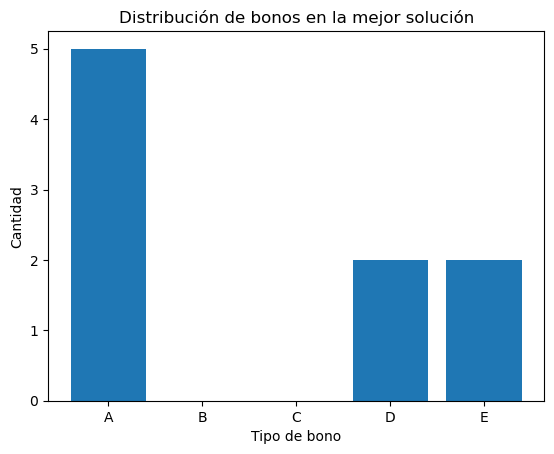

In [11]:
from deap import base, creator, tools, algorithms
import random
import matplotlib.pyplot as plt

precios = [500, 700, 300, 800, 400]
cantidades_max = [5, 6, 10, 3, 7]
rendimientos = [0.15, 0.05, 0.03, 0.10, 0.10]
capital = 5000
labels = ["A", "B", "C", "D", "E"]

def evaluar(individuo):
    costo = sum(individuo[i] * precios[i] for i in range(len(individuo)))
    rendimiento_total = sum(individuo[i] * precios[i] * rendimientos[i] for i in range(len(individuo)))
    
    if costo > capital:
        return -100000,
    
    return rendimiento_total,

def ajustar(individuo):
    for i in range(len(individuo)):
        if individuo[i] < 0:
            individuo[i] = 0
        elif individuo[i] > cantidades_max[i]:
            individuo[i] = cantidades_max[i]
    
    while sum(individuo[i] * precios[i] for i in range(len(individuo))) > capital:
        pos = random.randint(0, len(individuo) - 1)
        if individuo[pos] > 0:
            individuo[pos] -= 1
    
    return individuo

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

for i in range(len(cantidades_max)):
    toolbox.register(f"attr_{i}", random.randint, 0, cantidades_max[i])

toolbox.register(
    "individual",
    tools.initCycle,
    creator.Individual,
    (toolbox.attr_0, toolbox.attr_1, toolbox.attr_2, toolbox.attr_3, toolbox.attr_4),
    n=1
)

toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", evaluar)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutUniformInt, low=0, up=max(cantidades_max), indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

poblacion = toolbox.population(n=20)

for ind in poblacion:
    ajustar(ind)

# Algoritmo genético
NGEN = 100
for gen in range(NGEN):
    hijos = algorithms.varAnd(poblacion, toolbox, cxpb=0.7, mutpb=0.2)
    
    for ind in hijos:
        ajustar(ind)
        ind.fitness.values = toolbox.evaluate(ind)
    
    poblacion = toolbox.select(hijos, k=len(poblacion))

# Mejor solución
mejor = tools.selBest(poblacion, 1)[0]

costo_final = sum(mejor[i] * precios[i] for i in range(len(mejor)))
rendimiento_final = sum(mejor[i] * precios[i] * rendimientos[i] for i in range(len(mejor)))

print("Mejor combinación:", mejor)
print("Capital usado:", costo_final)
print("Rendimiento:", rendimiento_final)

# Gráfica
plt.figure()
plt.bar(labels, mejor)
plt.xlabel("Tipo de bono")
plt.ylabel("Cantidad")
plt.title("Distribución de bonos en la mejor solución")
plt.show()

### Comparación

Al comparar ambas soluciones, se puede ver que las dos llegan al mismo resultado en lo importante: usan 4900 de capital y generan un rendimiento de 615.0. Esto significa que los dos métodos funcionan bien y logran el objetivo del problema. La diferencia está en cómo reparten los bonos. El código del libro da [5, 0, 0, 1, 4], mientras que el de DEAP da [5, 0, 0, 2, 2], pero aun así ambos generan el mismo rendimiento, lo que muestra que hay más de una forma de llegar a una buena solución.

Sobre la función objetivo, en los dos casos se calcula el rendimiento total, solo que en el código del libro está más directo, y en DEAP se hace dentro del fitness porque así trabaja la librería. En cuanto al fitness, en el código del libro prácticamente es el mismo rendimiento, mientras que en DEAP está más estructurado y puede incluir penalizaciones si se pasa del capital.

Por último, la principal diferencia está en cómo se hacen los operadores genéticos. En el código del libro todo está hecho manualmente, lo que ayuda a entender mejor cómo funciona el algoritmo. En cambio, en DEAP ya vienen funciones listas para usar, lo que hace el código más fácil y rápido de implementar. En general, los dos enfoques son correctos, solo que uno es más explicativo y el otro más práctico.
